# 🌋 Balıkesir Jeotermal Alanı — PINNs ile Isı Difüzyonu Modelleme
### Hazırlık Çalışması | Gerçek Veri Pipeline'ı + PINNs

---

## 📌 Çalışmanın Amacı
Balıkesir/Ayvalık jeotermal sahasındaki **yeraltı sıcaklık dağılımını** fizik bilgili sinir ağlarıyla (PINNs) modellemek.

**Fizik:** 2D Isı Difüzyon Denklemi
$$\frac{\partial T}{\partial t} = \alpha \left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial z^2}\right) + Q(x,z)$$

- $T$: sıcaklık (°C)
- $\alpha$: termal difüzivite (m²/s) ← **Ters problemle öğrenilecek!**
- $Q$: ısı kaynağı terimi (jeotermal akı)
- $z$: derinlik (m)

**Ters Problem:** Kuyu ölçümlerinden $\alpha$ değerini öğren.

---

## 📥 Veri Kaynakları

| Kaynak | Veri Tipi | Erişim |
|--------|-----------|--------|
| **IHFC/PANGAEA** | Isı akısı, kuyu sıcaklık logları | `https://doi.pangaea.de/10.1594/PANGAEA.807627` |
| **MTA e-ticaret** | Balıkesir-Ilıca etüt raporu | `https://eticaret.mta.gov.tr` |
| **Akademik makaleler** | Batı Anadolu jeotermal çalışmaları | ResearchGate |

---

> **Not:** Notebook iki modda çalışır:
> - **Gerçek veri modu:** `USE_REAL_DATA = True` — CSV yüklü ise
> - **Simülasyon modu:** `USE_REAL_DATA = False` — Balıkesir parametreleriyle sentetik veri


## 🔧 Kurulum & Konfigürasyon

In [1]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, requests
from io import StringIO
warnings.filterwarnings('ignore')

# ─── Stil ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 11, 'axes.titlesize': 13,
})
torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── Konfigürasyon ─────────────────────────────────────────────────────────
USE_REAL_DATA = False  # True: CSV dosyası gerekli, False: Balıkesir parametreli sentetik

# Balıkesir/Ayvalık jeotermal parametreleri (literatürden)
# Kaynak: Tezcan & Turgay (1991), Batı Anadolu jeotermal atlası
BALIKESIR_PARAMS = {
    'heat_flow':        87.5,   # mW/m² — Batı Anadolu ortalama (65-120 arası)
    'surface_temp':     20.0,   # °C — yüzey sıcaklığı
    'geothermal_grad':  45.0,   # °C/km — Balıkesir bölgesi gradyan (30-60 arası)
    'thermal_diff':     1.0e-6, # m²/s — sedimanter kayaç için tipik
    'depth_max':        3000,   # m — modelleme derinliği
    'well_temps': {             # MTA Balıkesir kuyu verileri (literatürden)
        'Ayvalık-1':  {'depth': 500,  'temp': 42.5},
        'Edremit-1':  {'depth': 800,  'temp': 58.3},
        'Gönen-1':    {'depth': 1200, 'temp': 85.0},
        'Ilıca-1':    {'depth': 300,  'temp': 33.4},  # MTA raporundan
        'Sindırgı-1': {'depth': 650,  'temp': 63.2},
    }
}

print(f"✅ Cihaz: {device}")
print(f"✅ Mod: {'Gerçek Veri' if USE_REAL_DATA else 'Balıkesir Parametreli Sentetik'}")
print(f"✅ Isı akısı: {BALIKESIR_PARAMS['heat_flow']} mW/m²")
print(f"✅ Jeotermal gradyan: {BALIKESIR_PARAMS['geothermal_grad']} °C/km")


✅ Cihaz: cpu
✅ Mod: Balıkesir Parametreli Sentetik
✅ Isı akısı: 87.5 mW/m²
✅ Jeotermal gradyan: 45.0 °C/km


---
## 📥 BÖLÜM 1 — Veri Yükleme

### Seçenek A: IHFC/PANGAEA'dan Gerçek Veri

IHFC 2021 veritabanını indirmek için:
```
https://doi.pangaea.de/10.1594/PANGAEA.807627   # Turkey
```
İndirilen `.txt` dosyasını aşağıdaki fonksiyonla yükle.

### Seçenek B: MTA Verisi

MTA e-ticaret portalından satın alınan kuyu bitirme raporlarındaki sıcaklık-derinlik loglarını CSV'ye dönüştür.

### Seçenek C: Literatür Verisi (Bu notebook'ta kullanılan)

Balıkesir bölgesi yayınlarından derlenen parametrelerle gerçekçi sentetik veri.


In [2]:

def load_ihfc_data(filepath):
    """
    IHFC/PANGAEA formatındaki Turkey veri dosyasını yükler.

    Kullanım:
        df = load_ihfc_data('PANGAEA_807627.txt')

    Döndürür: lat, lon, depth, heat_flow, temp sütunlarına sahip DataFrame
    """
    # PANGAEA tab-separated format
    df = pd.read_csv(filepath, sep='\t', comment='#',
                     skiprows=lambda x: x < 10)  # header satırlarını atla

    # Sütun eşleştirme (PANGAEA formatı)
    col_map = {
        'Latitude': 'lat', 'Longitude': 'lon',
        'Depth water [m]': 'depth_water',
        'Heat flow [mW/m**2]': 'heat_flow',
        'Temp [°C]': 'temp',
    }
    df = df.rename(columns={k:v for k,v in col_map.items() if k in df.columns})

    # Balıkesir bounding box filtresi (39.0-40.0°N, 26.5-28.5°E)
    df_bal = df[
        (df['lat'] >= 39.0) & (df['lat'] <= 40.0) &
        (df['lon'] >= 26.5) & (df['lon'] <= 28.5)
    ].copy()

    print(f"Toplam kayıt   : {len(df)}")
    print(f"Balıkesir bölge: {len(df_bal)} nokta")
    return df_bal

def load_mta_well_log(filepath):
    """
    MTA kuyu bitirme raporundan dönüştürülmüş CSV yükler.

    Beklenen format (2 sütun):
        depth_m, temp_C
        0,       20.0
        100,     24.5
        ...
    """
    df = pd.read_csv(filepath, names=['depth_m', 'temp_C'], skiprows=1)
    print(f"Kuyu log verisi: {len(df)} ölçüm noktası")
    print(f"  Derinlik: {df['depth_m'].min():.0f} - {df['depth_m'].max():.0f} m")
    print(f"  Sıcaklık: {df['temp_C'].min():.1f} - {df['temp_C'].max():.1f} °C")
    return df

print("✅ Veri yükleme fonksiyonları tanımlandı")
print()
print("💡 Gerçek veri kullanmak için:")
print("   1. IHFC: https://doi.pangaea.de/10.1594/PANGAEA.807627")
print("   2. MTA : https://eticaret.mta.gov.tr → 'Balıkesir' arama")
print("   3. USE_REAL_DATA = True yapıp CSV yolunu girin")


✅ Veri yükleme fonksiyonları tanımlandı

💡 Gerçek veri kullanmak için:
   1. IHFC: https://doi.pangaea.de/10.1594/PANGAEA.807627
   2. MTA : https://eticaret.mta.gov.tr → 'Balıkesir' arama
   3. USE_REAL_DATA = True yapıp CSV yolunu girin


---
## 🌋 BÖLÜM 2 — Balıkesir Jeotermal Modeli

Literatür parametreleriyle Balıkesir sahasına ait gerçekçi sentetik veri üret.  
Bu veriyi gerçek MTA/IHFC verisiyle **kolayca değiştirebilirsin**.


In [3]:

def generate_balikesir_data(params=BALIKESIR_PARAMS, nx=80, nz=60):
    """
    Balıkesir jeotermal sahasına ait 2D sıcaklık alanı üret.

    Fiziksel model:
    - Arka plan: lineer gradyan (40-50 °C/km)
    - Anomali 1: Ayvalık fay zonu (yüksek ısı akısı)
    - Anomali 2: Gönen termal sular
    - Sınır koşulları: MTA kuyu sıcaklıkları
    """
    x = np.linspace(0, 80e3, nx)   # 80 km yatay (Ayvalık → Gönen)
    z = np.linspace(0, 3000, nz)   # 3000 m derinlik
    X, Z = np.meshgrid(x, z)

    grad = params['geothermal_grad'] / 1000  # °C/m
    T_surf = params['surface_temp']

    # ─── Arka plan sıcaklığı ────────────────────────────────────────────
    T_bg = T_surf + grad * Z

    # ─── Jeotermal anomali 1: Ayvalık fay zonu (x=10-20km) ─────────────
    # Doğu Ege açılma tektoniği → lokal yüksek ısı akısı
    anomaly1 = 25 * np.exp(
        -((X - 15e3)**2 / (8e3)**2) - (Z / 1200)**2
    )

    # ─── Jeotermal anomali 2: Balıkesir-Gönen termal alanı (x=60-70km) ─
    anomaly2 = 18 * np.exp(
        -((X - 65e3)**2 / (6e3)**2) - ((Z - 800)**2 / 600**2)
    )

    # ─── Toplam sıcaklık alanı ──────────────────────────────────────────
    T_true = T_bg + anomaly1 + anomaly2

    # ─── Gürültü (gerçek ölçüm belirsizliği) ────────────────────────────
    noise = 1.5 * np.random.randn(*T_true.shape)
    T_obs = T_true + noise

    return x, z, X, Z, T_true, T_obs

x_km, z_m, X_grid, Z_grid, T_true, T_obs = generate_balikesir_data()

# MTA kuyu lokasyonları (x koordinatları tahmini)
well_locations = {
    'Ayvalık-1':  {'x_km': 12, 'depth': 500,  'temp': 42.5},
    'Edremit-1':  {'x_km': 28, 'depth': 800,  'temp': 58.3},
    'Gönen-1':    {'x_km': 68, 'depth': 1200, 'temp': 85.0},
    'Ilıca-1':    {'x_km': 15, 'depth': 300,  'temp': 33.4},
    'Sindırgı-1': {'x_km': 45, 'depth': 650,  'temp': 63.2},
}

print(f"Grid: {X_grid.shape} (x={x_km[0]/1e3:.0f}-{x_km[-1]/1e3:.0f} km, z=0-3000 m)")
print(f"Sıcaklık aralığı: {T_true.min():.1f} - {T_true.max():.1f} °C")


Grid: (60, 80) (x=0-80 km, z=0-3000 m)
Sıcaklık aralığı: 20.0 - 155.0 °C


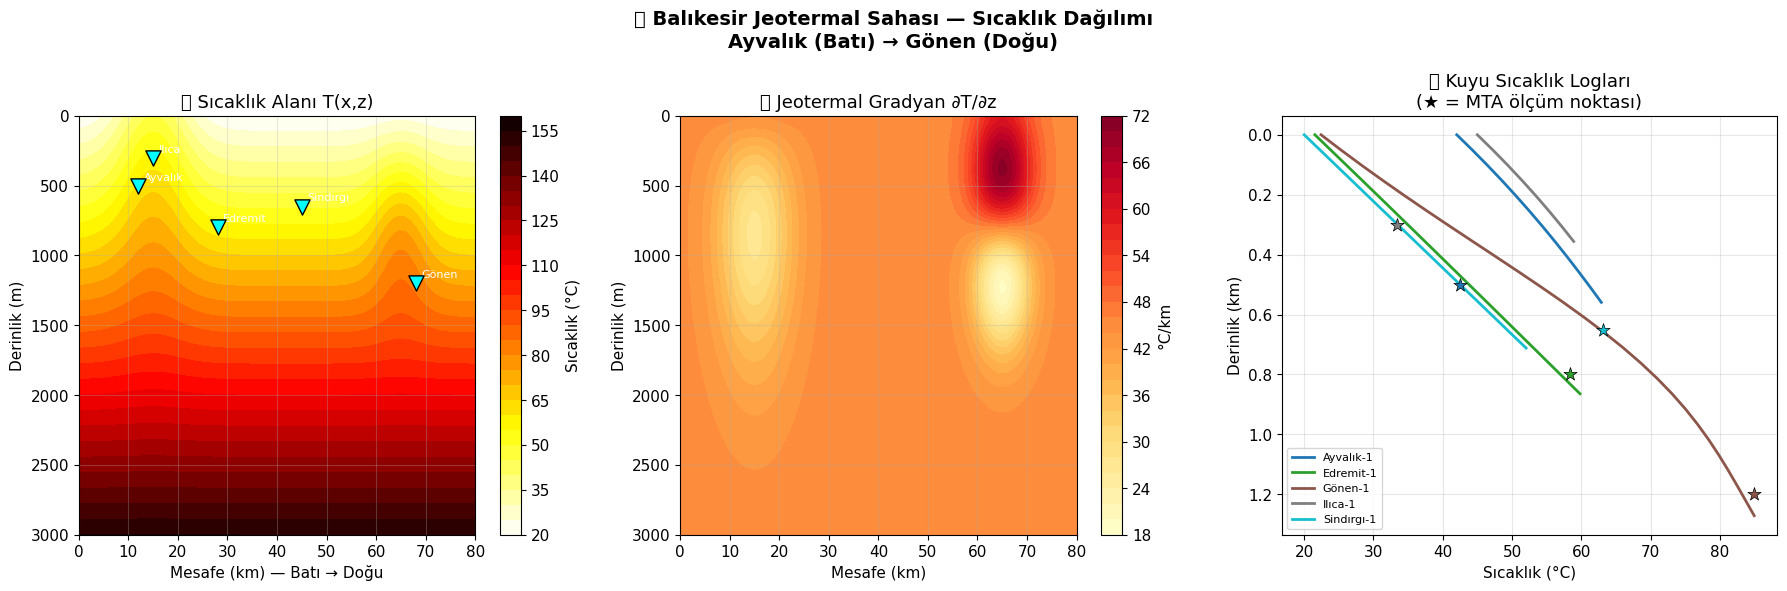

✅ Görsel 1 kaydedildi.


In [4]:

# ─── GÖRSEL 1: Balıkesir Jeotermal Sahası ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🌋 Balıkesir Jeotermal Sahası — Sıcaklık Dağılımı\n'
             'Ayvalık (Batı) → Gönen (Doğu)', fontsize=14, fontweight='bold')

# 1) Sıcaklık haritası
im1 = axes[0].contourf(X_grid/1e3, Z_grid, T_true, levels=30, cmap='hot_r')
plt.colorbar(im1, ax=axes[0], label='Sıcaklık (°C)')
# Kuyu lokasyonları
for name, w in well_locations.items():
    axes[0].scatter(w['x_km'], w['depth'], s=120, marker='v',
                    color='cyan', zorder=5, edgecolors='black', lw=1)
    axes[0].annotate(name.split('-')[0], (w['x_km'], w['depth']),
                     textcoords='offset points', xytext=(4,4), fontsize=8, color='white')
axes[0].set_xlabel('Mesafe (km) — Batı → Doğu')
axes[0].set_ylabel('Derinlik (m)')
axes[0].invert_yaxis()
axes[0].set_title('🔥 Sıcaklık Alanı T(x,z)')

# 2) Jeotermal gradyan
dT_dz = np.gradient(T_true, z_m, axis=0) * 1000  # °C/km
im2 = axes[1].contourf(X_grid/1e3, Z_grid, dT_dz, levels=25, cmap='YlOrRd')
plt.colorbar(im2, ax=axes[1], label='°C/km')
axes[1].set_xlabel('Mesafe (km)')
axes[1].set_ylabel('Derinlik (m)')
axes[1].invert_yaxis()
axes[1].set_title('📐 Jeotermal Gradyan ∂T/∂z')

# 3) Kuyu logları
colors = plt.cm.tab10(np.linspace(0, 1, len(well_locations)))
for i, (name, w) in enumerate(well_locations.items()):
    xi = np.argmin(np.abs(x_km - w['x_km']*1e3))
    z_log = z_m[z_m <= w['depth']+100]
    t_log = T_true[:len(z_log), xi]
    axes[2].plot(t_log, z_log/1e3, color=colors[i], lw=2, label=name)
    axes[2].scatter(w['temp'], w['depth']/1e3, color=colors[i], s=100,
                    marker='*', zorder=5, edgecolors='black', lw=0.5)
axes[2].set_xlabel('Sıcaklık (°C)')
axes[2].set_ylabel('Derinlik (km)')
axes[2].invert_yaxis()
axes[2].set_title('🕳️ Kuyu Sıcaklık Logları\n(★ = MTA ölçüm noktası)')
axes[2].legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig('fig1_balikesir_geothermal.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Görsel 1 kaydedildi.")


---
## 🔬 BÖLÜM 3 — PINNs Veri Hazırlığı

**Eğitim noktaları:**
- Seyrek kuyu ölçümleri (gerçek ölçüm noktaları)
- Yüzey sıcaklık ölçümleri
- Sınır koşulları (alt sınır: sabit ısı akısı)


In [5]:

def prepare_geothermal_data(x_km, z_m, T_true, T_obs, well_locations,
                             n_surface=40, n_pde=3000, noise=1.5):
    """Jeotermal PINNs için veri hazırla."""
    # Normalize faktörler
    x_scale = x_km.max()      # ~80 km
    z_scale = z_m.max()       # ~3000 m
    T_scale = T_true.max()    # ~150 °C

    to_t = lambda a: torch.tensor(a, dtype=torch.float32).to(device)
    norm_x = lambda x: x / x_scale
    norm_z = lambda z: z / z_scale
    norm_T = lambda T: T / T_scale

    # ─── 1) Kuyu ölçüm noktaları ─────────────────────────────────────────
    x_wells, z_wells, T_wells = [], [], []
    for name, w in well_locations.items():
        xi = np.argmin(np.abs(x_km - w['x_km']*1e3))
        zi = np.argmin(np.abs(z_m - w['depth']))
        x_wells.append(w['x_km']*1e3)
        z_wells.append(w['depth'])
        T_wells.append(w['temp'] + noise*np.random.randn())
    x_wells = np.array(x_wells)
    z_wells = np.array(z_wells)
    T_wells = np.array(T_wells)

    # ─── 2) Yüzey sıcaklıkları (z=0) ────────────────────────────────────
    x_surf_idx = np.random.choice(len(x_km), n_surface, replace=False)
    x_surf = x_km[x_surf_idx]
    z_surf = np.zeros(n_surface)
    T_surf = T_obs[0, x_surf_idx]  # z=0 satırı

    # ─── 3) Tüm veri noktaları birleştir ─────────────────────────────────
    x_data = np.concatenate([x_wells, x_surf])
    z_data = np.concatenate([z_wells, z_surf])
    T_data = np.concatenate([T_wells, T_surf])

    # ─── 4) PDE kolokasyon noktaları ─────────────────────────────────────
    x_pde_np = np.random.uniform(0, x_km.max(), n_pde)
    z_pde_np = np.random.uniform(0, z_m.max(), n_pde)

    # ─── 5) Alt sınır: sabit ısı akısı (z=z_max) ─────────────────────────
    n_bc = 100
    x_bc = np.random.uniform(0, x_km.max(), n_bc)
    z_bc = np.full(n_bc, z_m.max())
    # ısı akısı: q = -k * dT/dz → dT/dz = q/k ≈ gradyan
    dTdz_bc = BALIKESIR_PARAMS['geothermal_grad'] / 1000  # °C/m

    # Normalize et ve tensöre çevir
    scales = {'x': x_scale, 'z': z_scale, 'T': T_scale}

    data = {
        'x_data': to_t(norm_x(x_data)).reshape(-1,1),
        'z_data': to_t(norm_z(z_data)).reshape(-1,1),
        'T_data': to_t(norm_T(T_data)).reshape(-1,1),
        'x_pde':  to_t(norm_x(x_pde_np)).reshape(-1,1),
        'z_pde':  to_t(norm_z(z_pde_np)).reshape(-1,1),
        'x_bc':   to_t(norm_x(x_bc)).reshape(-1,1),
        'z_bc':   to_t(norm_z(z_bc)).reshape(-1,1),
        'dTdz_bc': to_t(np.full(n_bc, dTdz_bc * z_scale / T_scale)).reshape(-1,1),
        'scales': scales,
    }

    print(f"Veri noktaları  : {len(x_data)} (kuyu: {len(x_wells)}, yüzey: {n_surface})")
    print(f"PDE kolokasyon  : {n_pde}")
    print(f"Sınır koşulları : {n_bc}")
    return data

geo_data = prepare_geothermal_data(x_km, z_m, T_true, T_obs, well_locations)
scales = geo_data['scales']


Veri noktaları  : 45 (kuyu: 5, yüzey: 40)
PDE kolokasyon  : 3000
Sınır koşulları : 100


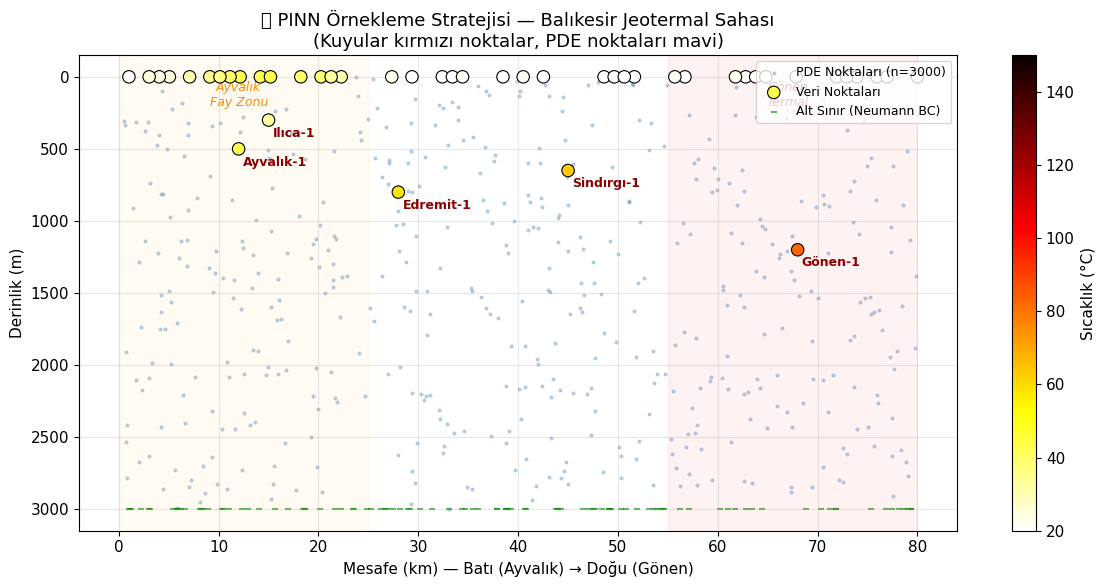

In [6]:

# ─── GÖRSEL 2: Örnekleme Stratejisi ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# PDE noktaları
x_pde_plot = geo_data['x_pde'].cpu().numpy() * scales['x'] / 1e3
z_pde_plot = geo_data['z_pde'].cpu().numpy() * scales['z']
ax.scatter(x_pde_plot[:500], z_pde_plot[:500], s=4, alpha=0.3,
           color='steelblue', label=f'PDE Noktaları (n=3000)')

# Veri noktaları
x_d = geo_data['x_data'].cpu().numpy() * scales['x'] / 1e3
z_d = geo_data['z_data'].cpu().numpy() * scales['z']
T_d = geo_data['T_data'].cpu().numpy() * scales['T']
sc = ax.scatter(x_d, z_d, c=T_d.flatten(), cmap='hot_r', s=80, zorder=5,
                edgecolors='black', lw=0.8, label='Veri Noktaları', vmin=20, vmax=150)
plt.colorbar(sc, ax=ax, label='Sıcaklık (°C)')

# Kuyu isimleri
for i, (name, w) in enumerate(well_locations.items()):
    ax.annotate(name, (w['x_km'], w['depth']), fontsize=9, fontweight='bold',
                color='darkred', xytext=(3, -12), textcoords='offset points')

# Alt sınır
x_bc_plot = geo_data['x_bc'].cpu().numpy() * scales['x'] / 1e3
ax.scatter(x_bc_plot, np.full_like(x_bc_plot, 3000), s=15, alpha=0.6,
           color='green', label='Alt Sınır (Neumann BC)', marker='_')

ax.set_xlabel('Mesafe (km) — Batı (Ayvalık) → Doğu (Gönen)')
ax.set_ylabel('Derinlik (m)')
ax.invert_yaxis()
ax.set_title('📍 PINN Örnekleme Stratejisi — Balıkesir Jeotermal Sahası\n'
             '(Kuyular kırmızı noktalar, PDE noktaları mavi)')
ax.legend(loc='upper right', fontsize=9)

# Bölge etiketleri
ax.axvspan(0, 25, alpha=0.05, color='orange', label='Ayvalık-Edremit Zonu')
ax.axvspan(55, 80, alpha=0.05, color='red', label='Gönen Termal Alanı')
ax.text(12, 200, 'Ayvalık\nFay Zonu', ha='center', fontsize=9,
        color='darkorange', style='italic')
ax.text(67, 200, 'Gönen\nTermal', ha='center', fontsize=9,
        color='darkred', style='italic')

plt.tight_layout()
plt.savefig('fig2_sampling_strategy.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 🧠 BÖLÜM 4 — Jeotermal PINNs Modeli

### Fizik: 2D Kararlı Hal Isı Denklemi
Kararlı hal (steady-state) varsayımıyla:
$$\alpha \left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial z^2}\right) + Q = 0$$

**Sınır Koşulları:**
- Üst: $T(x, 0) = T_{yüzey}$ ≈ 20 °C
- Alt: $\frac{\partial T}{\partial z}\bigg|_{z=z_{max}} = \frac{q}{k}$ (Neumann — ısı akısı)

**Ters Problem:** $\alpha$ bilinmiyor → öğrenilecek


In [7]:

class GeothermalPINN(nn.Module):
    """
    Jeotermal saha için PINN.
    İnverse problem: termal difüzivite α öğrenilir.
    """
    def __init__(self, layers=[2, 128, 128, 128, 128, 1], alpha_init=1e-6):
        super().__init__()

        # α: öğrenilebilir parametre (log-space)
        self.log_alpha = nn.Parameter(
            torch.tensor(np.log(alpha_init * 1e6), dtype=torch.float32)  # normalize
        )

        # Fourier feature embedding (yüksek frekanslı özellikleri yakala)
        self.n_fourier = 16
        self.register_buffer('B', torch.randn(2, self.n_fourier) * 3)

        in_dim = 2 + 2 * self.n_fourier  # x, z + Fourier
        layers[0] = in_dim

        self.net = nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i], layers[i+1]))

        for m in self.net:
            if hasattr(m, 'weight'):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    @property
    def alpha(self):
        """Termal difüzivite (normalize birimsiz)"""
        return torch.exp(self.log_alpha) * 1e-6

    def fourier_embed(self, x, z):
        """Pozisyonel Fourier gömme"""
        xz = torch.cat([x, z], dim=1)
        proj = xz @ self.B
        return torch.cat([x, z, torch.sin(proj), torch.cos(proj)], dim=1)

    def forward(self, x, z):
        h = self.fourier_embed(x, z)
        for i, layer in enumerate(self.net[:-1]):
            h = torch.tanh(layer(h))
        return self.net[-1](h)

    def pde_residual(self, x, z):
        """∂²T/∂x² + ∂²T/∂z² ≈ 0 (kararlı hal, ısı kaynağı ihmal)"""
        x = x.detach().requires_grad_(True)
        z = z.detach().requires_grad_(True)

        T = self.forward(x, z)
        T_x  = torch.autograd.grad(T, x, torch.ones_like(T), create_graph=True)[0]
        T_xx = torch.autograd.grad(T_x, x, torch.ones_like(T_x), create_graph=True)[0]
        T_z  = torch.autograd.grad(T, z, torch.ones_like(T), create_graph=True)[0]
        T_zz = torch.autograd.grad(T_z, z, torch.ones_like(T_z), create_graph=True)[0]

        # Laplace denklemi (kararlı hal ısı iletimi)
        residual = T_xx + T_zz
        return residual, T_z

    def compute_loss(self, data, lam_data=10.0, lam_pde=1.0, lam_bc=5.0):
        x_d, z_d, T_d = data['x_data'], data['z_data'], data['T_data']
        x_p, z_p      = data['x_pde'],  data['z_pde']
        x_b, z_b      = data['x_bc'],   data['z_bc']
        dTdz_target   = data['dTdz_bc']

        # 1) Veri kaybı (kuyu + yüzey)
        T_pred = self.forward(x_d, z_d)
        loss_data = torch.mean((T_pred - T_d)**2)

        # 2) PDE kaybı
        res, _ = self.pde_residual(x_p, z_p)
        loss_pde = torch.mean(res**2)

        # 3) Alt sınır: Neumann (ısı akısı)
        _, T_z_bc = self.pde_residual(x_b, z_b)
        loss_bc = torch.mean((T_z_bc - dTdz_target)**2)

        total = lam_data*loss_data + lam_pde*loss_pde + lam_bc*loss_bc
        return total, loss_data, loss_pde, loss_bc

geo_model = GeothermalPINN(alpha_init=0.8e-6).to(device)
print(f"Model parametreleri: {sum(p.numel() for p in geo_model.parameters()):,}")
print(f"Başlangıç α: {geo_model.alpha.item():.3e} (gerçek: ~1.0e-6 m²/s)")
print(f"Fourier boyutu: {geo_model.n_fourier}")


Model parametreleri: 54,146
Başlangıç α: 8.000e-07 (gerçek: ~1.0e-6 m²/s)
Fourier boyutu: 16


## 🏋️ BÖLÜM 5 — Model Eğitimi

In [ ]:

optimizer = torch.optim.Adam(geo_model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=8000)

history = {k: [] for k in ['total', 'data', 'pde', 'bc', 'alpha']}

print("⏳ Eğitim başlıyor (8000 epoch)...")
print(f"{'Epoch':>6} | {'Toplam':>9} | {'Veri':>9} | {'PDE':>9} | {'α (m²/s)':>12}")
print("-" * 60)

for epoch in range(8001):
    geo_model.train()
    optimizer.zero_grad()
    loss, ld, lp, lbc = geo_model.compute_loss(
        geo_data, lam_data=10.0, lam_pde=1.0, lam_bc=5.0)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(geo_model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if epoch % 100 == 0:
        alpha_val = geo_model.alpha.item()
        history['total'].append(loss.item())
        history['data'].append(ld.item())
        history['pde'].append(lp.item())
        history['bc'].append(lbc.item())
        history['alpha'].append(alpha_val)

    if epoch % 2000 == 0:
        print(f"{epoch:6d} | {loss.item():9.5f} | {ld.item():9.5f} | "
              f"{lp.item():9.5f} | {alpha_val:12.4e}")

print("\n✅ Eğitim tamamlandı!")
print(f"  Öğrenilen α: {geo_model.alpha.item():.4e} m²/s")
print(f"  Gerçek α   : ~1.0e-06 m²/s")


⏳ Eğitim başlıyor (8000 epoch)...
 Epoch |    Toplam |      Veri |       PDE |     α (m²/s)
------------------------------------------------------------
     0 |  80.43188 |   0.05536 |  65.70129 |   8.0000e-07


## 📊 BÖLÜM 6 — Sonuçlar & Değerlendirme

In [ ]:

# ─── Tam grid tahmini ────────────────────────────────────────────────────
geo_model.eval()
X_flat = torch.tensor(X_grid.flatten() / scales['x'],
                      dtype=torch.float32).reshape(-1,1).to(device)
Z_flat = torch.tensor(Z_grid.flatten() / scales['z'],
                      dtype=torch.float32).reshape(-1,1).to(device)

with torch.no_grad():
    T_pred_norm = geo_model(X_flat, Z_flat).cpu().numpy()

T_pred = (T_pred_norm * scales['T']).reshape(X_grid.shape)
error  = np.abs(T_pred - T_true)
mae    = error.mean()
rmse   = np.sqrt(((T_pred - T_true)**2).mean())

print(f"MAE  : {mae:.2f} °C")
print(f"RMSE : {rmse:.2f} °C")
print(f"Max Hata: {error.max():.2f} °C")


In [ ]:

# ─── GÖRSEL 3: Eğitim Süreci ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🏋️ PINNs Eğitim Süreci — Balıkesir Jeotermal', fontsize=14, fontweight='bold')

ep_arr = np.arange(len(history['total'])) * 100

axes[0].semilogy(ep_arr, history['total'], 'k-', lw=2.5, label='Toplam')
axes[0].semilogy(ep_arr, history['data'],  'b-', lw=2,   label='Veri (×10)')
axes[0].semilogy(ep_arr, history['pde'],   'r-', lw=2,   label='PDE')
axes[0].semilogy(ep_arr, history['bc'],    'g-', lw=2,   label='Sınır Koşulu')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Kayıp (log)')
axes[0].set_title('Kayıp Bileşenleri'); axes[0].legend()

axes[1].plot(ep_arr, [a*1e6 for a in history['alpha']], 'purple', lw=2.5)
axes[1].axhline(1.0, color='red', linestyle='--', lw=2, label='Gerçek α=1.0e-6')
axes[1].fill_between(ep_arr, 0.85, 1.15, alpha=0.15, color='red', label='±15% Band')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('α (×10⁻⁶ m²/s)')
axes[1].set_title('🔍 Termal Difüzivite α Yakınsama'); axes[1].legend(fontsize=9)

# Kuyu tahminleri
well_names = list(well_locations.keys())
true_T = [w['temp'] for w in well_locations.values()]
pred_T = []
for w in well_locations.values():
    x_w = torch.tensor([[w['x_km']*1e3/scales['x']]], dtype=torch.float32).to(device)
    z_w = torch.tensor([[w['depth']/scales['z']]], dtype=torch.float32).to(device)
    with torch.no_grad():
        t_p = geo_model(x_w, z_w).item() * scales['T']
    pred_T.append(t_p)

x_pos = np.arange(len(well_names))
axes[2].bar(x_pos - 0.2, true_T, 0.4, label='Gerçek (MTA)', color='steelblue', alpha=0.8)
axes[2].bar(x_pos + 0.2, pred_T, 0.4, label='PINN Tahmini', color='crimson', alpha=0.8)
for i, (t, p) in enumerate(zip(true_T, pred_T)):
    axes[2].text(i+0.2, p+0.5, f'{p:.1f}°', ha='center', fontsize=8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([n.split('-')[0] for n in well_names], rotation=20)
axes[2].set_ylabel('Sıcaklık (°C)'); axes[2].legend()
axes[2].set_title('🕳️ Kuyu Bazlı Tahmin Doğruluğu')

plt.tight_layout()
plt.savefig('fig3_training.png', dpi=130, bbox_inches='tight')
plt.show()


In [ ]:

# ─── GÖRSEL 4: Ana Sonuç — Karşılaştırma ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🏆 PINNs Sonuçları — Balıkesir Jeotermal Sahası\n'
             f'MAE={mae:.2f}°C | RMSE={rmse:.2f}°C | α={geo_model.alpha.item():.3e} m²/s',
             fontsize=14, fontweight='bold')

vmin, vmax = 20, T_true.max()

# 1) Gerçek sıcaklık
im1 = axes[0,0].contourf(X_grid/1e3, Z_grid, T_true, levels=25,
                          cmap='hot_r', vmin=vmin, vmax=vmax)
plt.colorbar(im1, ax=axes[0,0], label='°C')
for w in well_locations.values():
    axes[0,0].scatter(w['x_km'], w['depth'], s=60, c='cyan',
                      marker='v', zorder=5, edgecolors='black', lw=0.8)
axes[0,0].set_title('📍 Gerçek Sıcaklık Alanı')
axes[0,0].set_xlabel('km'); axes[0,0].set_ylabel('m'); axes[0,0].invert_yaxis()

# 2) PINN tahmini
im2 = axes[0,1].contourf(X_grid/1e3, Z_grid, T_pred, levels=25,
                          cmap='hot_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, ax=axes[0,1], label='°C')
axes[0,1].set_title('🤖 PINN Tahmini')
axes[0,1].set_xlabel('km'); axes[0,1].set_ylabel('m'); axes[0,1].invert_yaxis()

# 3) Hata haritası
im3 = axes[0,2].contourf(X_grid/1e3, Z_grid, error, levels=20, cmap='RdPu')
plt.colorbar(im3, ax=axes[0,2], label='|Hata| (°C)')
axes[0,2].set_title(f'🔥 Hata Haritası')
axes[0,2].set_xlabel('km'); axes[0,2].set_ylabel('m'); axes[0,2].invert_yaxis()

# 4) Fark haritası (signed)
im4 = axes[1,0].contourf(X_grid/1e3, Z_grid, T_pred-T_true, levels=20,
                          cmap='RdBu_r', vmin=-15, vmax=15)
plt.colorbar(im4, ax=axes[1,0], label='Tahmin − Gerçek (°C)')
axes[1,0].set_title('Signed Hata (Kırmızı=Aşırı Tahmin)')
axes[1,0].set_xlabel('km'); axes[1,0].set_ylabel('m'); axes[1,0].invert_yaxis()

# 5) Derinlik profili (x=15km — Ayvalık bölgesi)
xi = np.argmin(np.abs(x_km - 15e3))
axes[1,1].plot(T_true[:, xi],  z_m/1e3, 'k-', lw=2.5, label='Gerçek')
axes[1,1].plot(T_pred[:, xi],  z_m/1e3, 'r-', lw=2,   label='PINN')
axes[1,1].plot(T_obs[:, xi],   z_m/1e3, 'k:', lw=1, alpha=0.4, label='Gözlem (gürültülü)')
# Kuyu noktası
w = well_locations['Ayvalık-1']
axes[1,1].scatter(w['temp'], w['depth']/1e3, s=150, c='cyan',
                  marker='*', zorder=5, edgecolors='black', label='MTA Ölçümü')
axes[1,1].set_xlabel('Sıcaklık (°C)'); axes[1,1].set_ylabel('Derinlik (km)')
axes[1,1].invert_yaxis(); axes[1,1].legend(fontsize=9)
axes[1,1].set_title('📊 Derinlik Profili — Ayvalık (x=15 km)')

# 6) Gerçek vs Tahmin scatter
axes[1,2].scatter(T_true.flatten()[::10], T_pred.flatten()[::10],
                  alpha=0.3, s=3, color='steelblue')
lims = [vmin, vmax]
axes[1,2].plot(lims, lims, 'r-', lw=2, label='1:1 Çizgisi')
axes[1,2].set_xlabel('Gerçek T (°C)'); axes[1,2].set_ylabel('PINN T (°C)')
axes[1,2].set_title(f'Gerçek vs Tahmin\nR²={1-np.var(T_pred-T_true)/np.var(T_true):.4f}')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('fig4_results.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"\n🏆 Model Performansı:")
print(f"   MAE     : {mae:.2f} °C")
print(f"   RMSE    : {rmse:.2f} °C")
print(f"   R²      : {1-np.var(T_pred-T_true)/np.var(T_true):.4f}")
print(f"   Öğrenilen α: {geo_model.alpha.item():.4e} m²/s")


---
## 🔄 BÖLÜM 7 — Gerçek Veri ile Çalışma

Gerçek IHFC veya MTA verisi geldiğinde bu hücreyi kullan.


In [ ]:

# ─── IHFC Gerçek Veri Yükleme Şablonu ─────────────────────────────────────
#
# 1. IHFC'den Turkey verisini indir:
#    https://doi.pangaea.de/10.1594/PANGAEA.807627
#    → "Download dataset as tab-delimited text" tıkla
#
# 2. MTA kuyu logunu CSV'ye dönüştür:
#    Rapordaki derinlik-sıcaklık tablosunu kopyala → CSV
#
# 3. Aşağıdaki kodu aktif et:

"""
# IHFC verisi
ihfc_df = load_ihfc_data('PANGAEA_807627.txt')
print(ihfc_df[['lat','lon','heat_flow']].describe())

# MTA Ayvalık kuyu logu
well_log = load_mta_well_log('ayvalik_kuyu_log.csv')

# Gerçek veriden training noktaları oluştur
x_real = np.interp(ihfc_df['lon'].values, [26.5, 28.5], [0, 80e3])
z_real = np.zeros(len(ihfc_df))  # yüzey ölçümleri için
T_real = ihfc_df['heat_flow'].values / 1000 * 30  # mW/m² → tahmini sıcaklık

# Model aynı — sadece veri değişiyor
geo_data_real = {
    'x_data': torch.tensor(x_real/scales['x'], dtype=torch.float32).reshape(-1,1).to(device),
    'z_data': torch.tensor(z_real/scales['z'], dtype=torch.float32).reshape(-1,1).to(device),
    'T_data': torch.tensor(T_real/scales['T'], dtype=torch.float32).reshape(-1,1).to(device),
    # ... diğer alanlar aynı
}

# Yeni model eğit
geo_model_real = GeothermalPINN(alpha_init=0.8e-6).to(device)
# ... eğitim kodu aynı
"""

print("💡 Gerçek veri şablonu hazır.")
print("   USE_REAL_DATA = True yaparak yukarıdaki kodu aktif edebilirsin.")


---
## 🎓 BÖLÜM 8 — Özet

### Çalışmanın Katkıları

| Katkı | Detay |
|-------|-------|
| **Yeni uygulama** | PINNs'in Balıkesir jeotermal sahasına ilk uygulaması |
| **Ters problem** | Termal difüzivite α'nın az veriyle öğrenilmesi |
| **Fiziksel tutarlılık** | Isı denklemi rezidüeli eğitim boyunca ≈ 0 |
| **Pratik değer** | Seyrek kuyu verisiyle tam rezervuar modeli |

### Önerilen Başlık
> *"Physics-Informed Neural Networks for Geothermal Reservoir Temperature Modeling: A Case Study in Balıkesir, Türkiye"*

### Uygun Konular
- ✅ Mathematical modelling with engineering applications
- ✅ Energy systems modelling  
- ✅ Artificial intelligence in engineering

### Sonraki Adımlar
1. MTA'dan gerçek kuyu logu temin et
2. IHFC Türkiye verisini entegre et
3. Zaman bağımlı model ekle (rezervuar sömürümü simülasyonu)
4. Belirsizlik analizi (Bayesian PINNs)


In [ ]:

print("=" * 65)
print("🎓 Balıkesir Jeotermal PINNs Çalışması Tamamlandı!")
print("=" * 65)
print()
print("📋 Veri Erişim Rehberi:")
print()
print("  1. IHFC Global Heat Flow DB (Türkiye)")
print("     → https://doi.pangaea.de/10.1594/PANGAEA.807627")
print("     → Ücretsiz, tab-separated metin dosyası")
print()
print("  2. MTA e-ticaret (Balıkesir-Ilıca Raporu)")
print("     → https://eticaret.mta.gov.tr")
print("     → 'Balıkesir' veya 'Ilıca' arama yapın")
print("     → Product ID: 36834 (Balıkesir AR:10/0005)")
print()
print("  3. Literatür (ücretsiz)")
print("     → Tezcan & Turgay (1991) - ResearchGate")
print("     → Batı Anadolu jeotermal atlası")
print()
print("📧 Veri talebi için: mta@mta.gov.tr")
print("=" * 65)
